In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import os

In [15]:
data_path = "C:/Users/seraf/fisica_computazionale/progetto_ising/codice_parallelo"

In [16]:
magnetizzazione_df = pd.read_csv(os.path.join(data_path, "risultati_prova.csv"))

In [17]:
L_values = np.array(magnetizzazione_df['L'].unique())

In [18]:
beta_values = np.array(magnetizzazione_df['beta'].unique())

In [19]:

gruppi_L = magnetizzazione_df.groupby('L')

m = {}
err = {}

for L in L_values:
    # Salviamo l'intero array usando L come chiave
    m[L] = gruppi_L.get_group(L)['<M>'].values
    err[L] = gruppi_L.get_group(L)['errore su <M>'].values

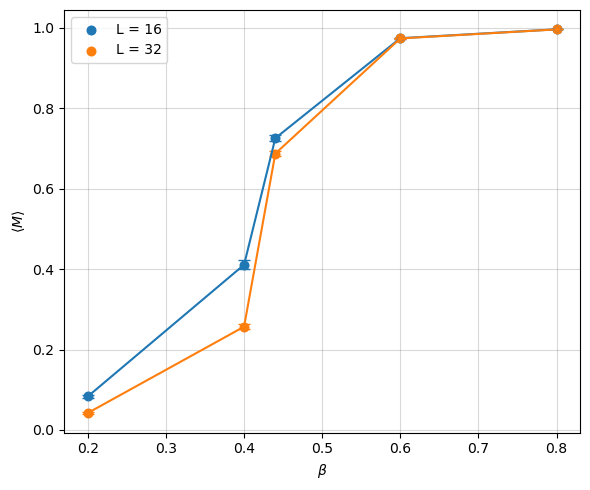

In [20]:
plt.figure(figsize=(6, 5))
for L in L_values:
    plt.scatter(beta_values, m[L], linewidth=1.2, linestyle='-', label='L = %d' %(L))
    plt.errorbar(beta_values, m[L], yerr=err[L], marker='o', linestyle='-', markersize=3, capsize=4)
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\langle M \rangle$')
plt.legend()
plt.grid(True, which='both', color='gray', alpha=0.3)
plt.tight_layout()
plt.show()

Leggendo i dati da C:/Users/seraf/fisica_computazionale/progetto_ising/codice_parallelo\evoluzione_prova.csv...
Trovati 100 fotogrammi. Generazione della GIF in corso...


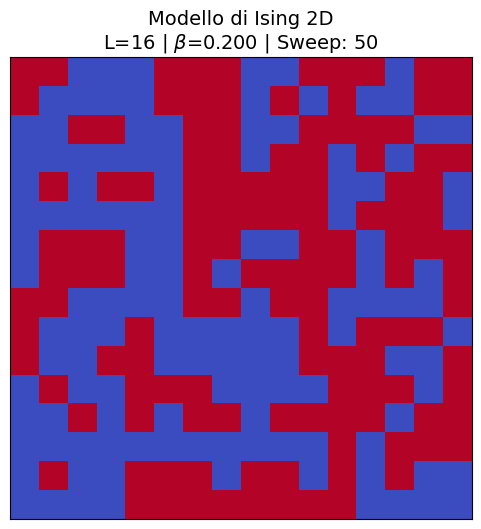

In [21]:
filename = os.path.join(data_path, "evoluzione_prova.csv")

# 2. Scegliamo cosa animare (Puoi cambiare questi valori!)
target_L = 16
target_beta = 0.2

frames = []
sweeps = []

print(f"Leggendo i dati da {filename}...")

# 3. Leggiamo il file e isoliamo solo i frame che ci interessano
with open(filename, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()
    # Cerchiamo l'intestazione del fotogramma
    if line.startswith("L:"):
        parts = line.split()
        L = int(parts[1])
        beta = float(parts[3])
        sweep = int(parts[5])
        
        i += 1 # Passiamo alla prima riga della matrice
        
        # Leggiamo la matrice L x L
        matrix = []
        for _ in range(L):
            row = [int(x) for x in lines[i].split()]
            matrix.append(row)
            i += 1
            
        # Se il frame corrisponde a L e Beta scelti, lo salviamo
        if L == target_L and abs(beta - target_beta) < 0.001:
            frames.append(np.array(matrix))
            sweeps.append(sweep)
    else:
        i += 1

if not frames:
    print("ERRORE: Nessun frame trovato per i parametri scelti. Controlla che L e Beta siano giusti!")
    exit()

print(f"Trovati {len(frames)} fotogrammi. Generazione della GIF in corso...")

# 4. Creiamo l'animazione
fig, ax = plt.subplots(figsize=(6, 6))

# Usiamo la colormap 'coolwarm' (Blu per gli spin -1, Rosso per gli spin +1)
cmap = plt.cm.coolwarm
matrice_plot = ax.imshow(frames[0], cmap=cmap, vmin=-1, vmax=1, interpolation='none')

# Togliamo i numeri dagli assi per renderlo più "pulito"
ax.set_xticks([])
ax.set_yticks([])
titolo = ax.set_title(f"Modello di Ising 2D\nL={target_L} | $\\beta$={target_beta:.3f} | Sweep: {sweeps[0]}", fontsize=14)

# Funzione che aggiorna il grafico a ogni fotogramma
def update(frame_idx):
    matrice_plot.set_data(frames[frame_idx])
    titolo.set_text(f"Modello di Ising 2D\nL={target_L} | $\\beta$={target_beta:.3f} | Sweep: {sweeps[frame_idx]}")
    return matrice_plot, titolo

# Creiamo l'oggetto animazione (intervallo di 100ms tra i frame)
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=False)

ani.save('./assets/ising_L%d_B%.3f.gif' %(target_L, target_beta), writer='pillow', fps=5)

File C:/Users/seraf/fisica_computazionale/progetto_ising/codice_parallelo/tempi_speedup_1.csv caricato correttamente.
File C:/Users/seraf/fisica_computazionale/progetto_ising/codice_parallelo/tempi_speedup_2.csv caricato correttamente.
File C:/Users/seraf/fisica_computazionale/progetto_ising/codice_parallelo/tempi_speedup_4.csv caricato correttamente.
File C:/Users/seraf/fisica_computazionale/progetto_ising/codice_parallelo/tempi_speedup_8.csv caricato correttamente.


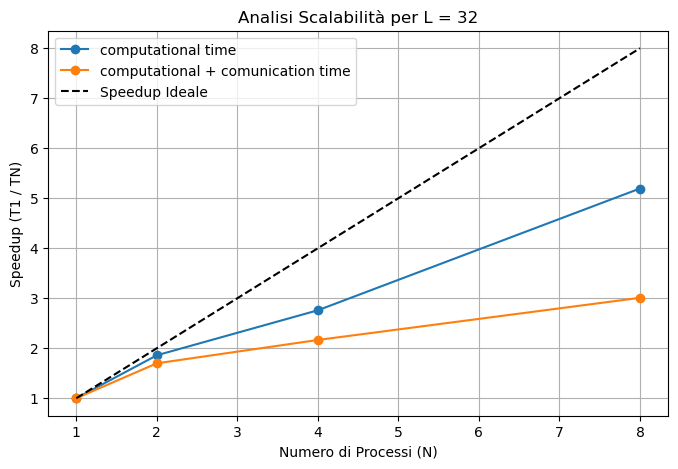

In [34]:
core_counts = [1, 2, 4, 8]

# Caricamento dei 4 DataFrame separati
# Usiamo un dizionario per accedervi facilmente: df_dict[1] sarà il df a 1 core
df_dict = {}
for n in core_counts:
    filename = f"{data_path}/tempi_speedup_{n}.csv"
    try:
        df_dict[n] = pd.read_csv(filename)
        print(f"File {filename} caricato correttamente.")
    except FileNotFoundError:
        print(f"Attenzione: Il file {filename} non è stato trovato.")

# Esempio di utilizzo: graficare lo speedup per una specifica L (es. L=64)
L_target = 32

plt.figure(figsize=(8, 5))

# Estraiamo i tempi totali per ogni configurazione di core per la L scelta
speedup_values = []
speedup_values_calcoli = []

for n in core_counts:
    if n in df_dict:
        # Recuperiamo il tempo per la L specificata
        df_n = df_dict[n]
        tempo = df_n[df_n['L'] == L_target]['total_time'].values[0]
        tempo_calcoli = df_n[df_n['L'] == L_target]['comp_time'].values[0]
        speedup_values.append(tempo)
        speedup_values_calcoli.append(tempo_calcoli)

# Calcoliamo lo speedup normalizzando rispetto al tempo a 1 core
t1 = speedup_values[0]
t1_calcoli = speedup_values_calcoli[0]
speedup_final = [t1 / t for t in speedup_values]
speedup_final_calcoli = [t1_calcoli / t for t in speedup_values_calcoli]

# Plot
plt.plot(core_counts, speedup_final_calcoli, marker='o', label='computational time')
plt.plot(core_counts, speedup_final, marker='o', label='computational + comunication time')
plt.plot(core_counts, core_counts, 'k--', label='Speedup Ideale')

plt.xlabel('Numero di Processi (N)')
plt.ylabel('Speedup (T1 / TN)')
plt.title(f'Analisi Scalabilità per L = {L_target}')
plt.legend()
plt.grid(True)
plt.show()